# Macroeconomic Scenarios

Thus far, our model has only taken into consideration the information available on the borrower. It has not at all considered external factors such as those related to the economy. In this notebook, we aim to implement post-model adjustments for different macroeconomic environments.

Let us load the original dataset and print the `issue_d` (issue date) column. The loans range from 2008 - 2017, which is a substantial period of time with many variations in the U.S. economy.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

#load original sample with default flat
df_raw = pd.read_csv('data/sample.csv', index_col=0)

#check issue date column and print counts
print(df_raw['issue_d'].value_counts().head(20))
print(df_raw['issue_d'].dtype)

issue_d
Mar-2016    2727
Oct-2015    2134
Aug-2018    2072
Oct-2018    2068
Jul-2015    2067
May-2018    2057
Dec-2015    1972
Nov-2017    1971
Nov-2018    1925
Aug-2017    1907
Jul-2018    1882
Apr-2018    1873
Jun-2018    1854
Sep-2018    1749
Dec-2018    1733
Jul-2017    1723
Nov-2015    1723
Sep-2017    1713
Oct-2014    1706
Mar-2018    1702
Name: count, dtype: int64
object


We see that dates are stored as `object` (strings). We shall use Python's `datetime` data type, but first we must convert the strings.

In [19]:
#convert issue_d to datetime
df_raw['issue_d'] = pd.to_datetime(df_raw['issue_d'], format='%b-%Y')
print(df_raw['issue_d'].value_counts().head(20))

issue_d
2016-03-01    2727
2015-10-01    2134
2018-08-01    2072
2018-10-01    2068
2015-07-01    2067
2018-05-01    2057
2015-12-01    1972
2017-11-01    1971
2018-11-01    1925
2017-08-01    1907
2018-07-01    1882
2018-04-01    1873
2018-06-01    1854
2018-09-01    1749
2018-12-01    1733
2017-07-01    1723
2015-11-01    1723
2017-09-01    1713
2014-10-01    1706
2018-03-01    1702
Name: count, dtype: int64


We shall look at the loans on a year-by-year basis. A model could look at loans quarter-by-quarter, or even month-by-month. However, due to the substantial year range, we deem year-by-year to be most appropriate. We then calculate the default rate per year using the `default_flag`.

In [20]:
#extract year
df_raw['issue_year'] = df_raw['issue_d'].dt.year

#calculate default rate by year and print
default_by_year = df_raw.groupby('issue_year')['default_flag'].agg(['mean', 'count'])
default_by_year.columns = ['default_rate', 'loan_count']
default_by_year = default_by_year.reset_index()
print(default_by_year)


    issue_year  default_rate  loan_count
0         2007      0.157895          19
1         2008      0.188889          90
2         2009      0.149194         248
3         2010      0.194393         535
4         2011      0.157205         916
5         2012      0.160965        2280
6         2013      0.159578        5972
7         2014      0.179045       10489
8         2015      0.183268       18743
9         2016      0.171685       19163
10        2017      0.111826       19575
11        2018      0.036602       21966


We can plot this information on a graph:

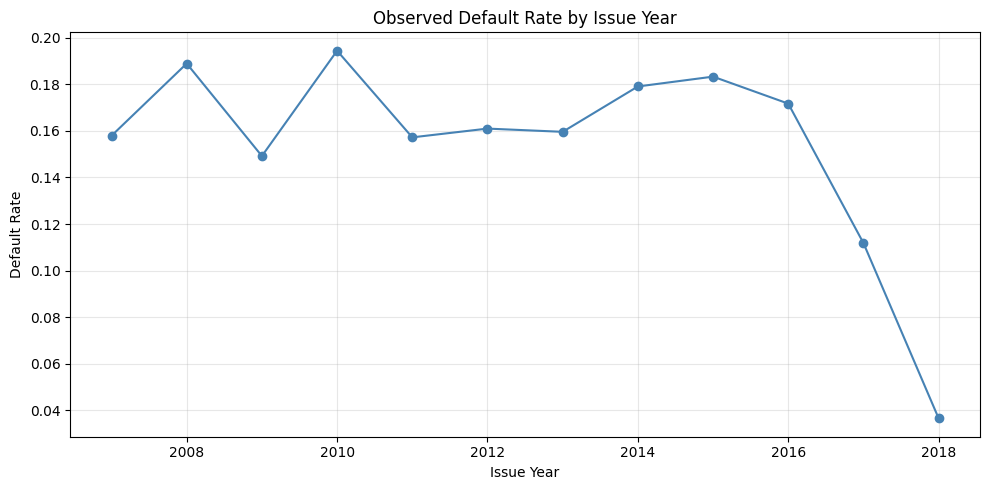

In [21]:
#plot
plt.figure(figsize=(10, 5))
plt.plot(default_by_year['issue_year'], default_by_year['default_rate'], 
         marker='o', color='steelblue', linewidth=1.5)
plt.xlabel('Issue Year')
plt.ylabel('Default Rate')
plt.title('Observed Default Rate by Issue Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This graph shows an interesting pattern. Firstly, we note that 2018 and 2017 have by far the least amount of defaults for loans issued in those years. This is likely due to the fact that the loans are relatively new and thus the borrowers have not had much opportunity to default (recall that these are all $36$ or $60$ month loans). This is an example of vintage bias. We shall choose to exclude 2017 and 2018 from our upcoming regression for this reason. The spikes in 2008 and 2018 are likely due to the Global Financial Crisis.

### Unemployment Rate

Recall that LendingClub is a U.S. based company. Although many macroeconomic factors are international, such as the 2008 Global Financial Crisis, there are still variations in impact across different countries. As such, we wish to find some U.S. macroeconomic data for the period shown above, in order to maximise accuracy. Let us begin with U.S. unemployment data, which is available from the Federal Reserve's API. We shall not include 2017 and 2010 for the reasons mentioned above.

In [22]:
#fetch US annual unemployment rate from FRED
#using pandas datareader to pull directly from FRED
import pandas_datareader.data as web
from datetime import datetime

#download US unemployment rate
unemployment = web.DataReader('UNRATE', 'fred', 
                               start=datetime(2007, 1, 1), 
                               end=datetime(2016, 12, 31))

#convert to annual average
unemployment.index = pd.to_datetime(unemployment.index)
unemployment_annual = unemployment.resample('YE').mean()
unemployment_annual.index = unemployment_annual.index.year
unemployment_annual.columns = ['unemployment_rate']

print(unemployment_annual)

      unemployment_rate
DATE                   
2007           4.616667
2008           5.800000
2009           9.283333
2010           9.608333
2011           8.933333
2012           8.075000
2013           7.358333
2014           6.158333
2015           5.275000
2016           4.875000


We see clearly the harsh impact of the Global Financial Crisis on unemployment rates in the U.S.; Now let us compare these with default rates.

In [23]:
#merge unemployment with default rates
#exclude 2017 and 2018 due to vintage bias
default_by_year_filtered = default_by_year[default_by_year['issue_year'] <= 2016].copy()

macro_df = default_by_year_filtered.merge(
    unemployment_annual,
    left_on='issue_year',
    right_index=True,
    how='inner'
)

#output
print(macro_df)

   issue_year  default_rate  loan_count  unemployment_rate
0        2007      0.157895          19           4.616667
1        2008      0.188889          90           5.800000
2        2009      0.149194         248           9.283333
3        2010      0.194393         535           9.608333
4        2011      0.157205         916           8.933333
5        2012      0.160965        2280           8.075000
6        2013      0.159578        5972           7.358333
7        2014      0.179045       10489           6.158333
8        2015      0.183268       18743           5.275000
9        2016      0.171685       19163           4.875000


Despite the low `loan_count` for 2007, we choose to still include this data as part of our regression. The reason for this is that it is the only data we have from before the Global Financial Crisis, and despite the small sample, the default rate appears in-line with what we might expect.

Let us plot the above relationship.

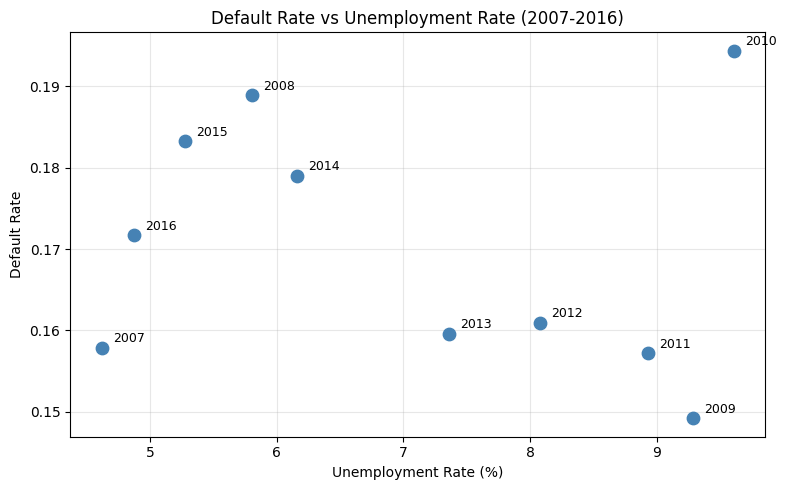

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(macro_df['unemployment_rate'], macro_df['default_rate'], 
            color='steelblue', s=80, zorder=5)

#label each point with the year
for _, row in macro_df.iterrows():
    plt.annotate(str(int(row['issue_year'])), 
                 (row['unemployment_rate'], row['default_rate']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)

plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Default Rate')
plt.title('Default Rate vs Unemployment Rate (2007-2016)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The graph is very scattered and does not show a clear pattern or trend. This is likely due to the fact that loans may be defaulted later into their term, in a different year to commencement. For example, a loan issued in 2009 may not have defaulted until 2010. So this default is reflected in the 2009 despite being associated with unemployment in 2010. We consider our options:
- The first option is to continue as is and accept the model limitation. Despite the abovementioned issue, there is still some value to the data. We see a clear spike in unemployment in 2009 followed by a spike in defaults in 2010, presumably as people begin to lose their savings. We also see steady default rates in the early 2010s, as banks issue more conservative and safe loans due to high unemployment.
- Another option is to use the loan term data to associate defaults with the year the loan was due rather than the year of commencement. However, loans default throughout the term, not at the end of their life. So this presents the same issue as before.
- The final and most sophisticated option is to plot lagged data for different time periods. So we push all loans forward by $12$ months and $24$ months, then compare the patterns to see what we can learn. We choose to try this method. This also removes our 2007 loan data, which we have identified as too small a sample.

In [25]:
#create lagged unemployment: associate unemployment in year 20XX with defaults in year 20XX+1
macro_df['unemployment_lagged_1y'] = macro_df['unemployment_rate'].shift(1)
macro_df['unemployment_lagged_2y'] = macro_df['unemployment_rate'].shift(2)

#drop the first row (or first two rows for 2 years) which has (have) no lagged value(s)
macro_df_lagged = macro_df.dropna(subset=['unemployment_lagged_1y'])
macro_df_lagged = macro_df.dropna(subset=['unemployment_lagged_2y'])

print(macro_df_lagged[['issue_year', 'default_rate', 'unemployment_rate', 'unemployment_lagged_1y','unemployment_lagged_2y']])

   issue_year  default_rate  unemployment_rate  unemployment_lagged_1y  \
2        2009      0.149194           9.283333                5.800000   
3        2010      0.194393           9.608333                9.283333   
4        2011      0.157205           8.933333                9.608333   
5        2012      0.160965           8.075000                8.933333   
6        2013      0.159578           7.358333                8.075000   
7        2014      0.179045           6.158333                7.358333   
8        2015      0.183268           5.275000                6.158333   
9        2016      0.171685           4.875000                5.275000   

   unemployment_lagged_2y  
2                4.616667  
3                5.800000  
4                9.283333  
5                9.608333  
6                8.933333  
7                8.075000  
8                7.358333  
9                6.158333  


Now let us plot.

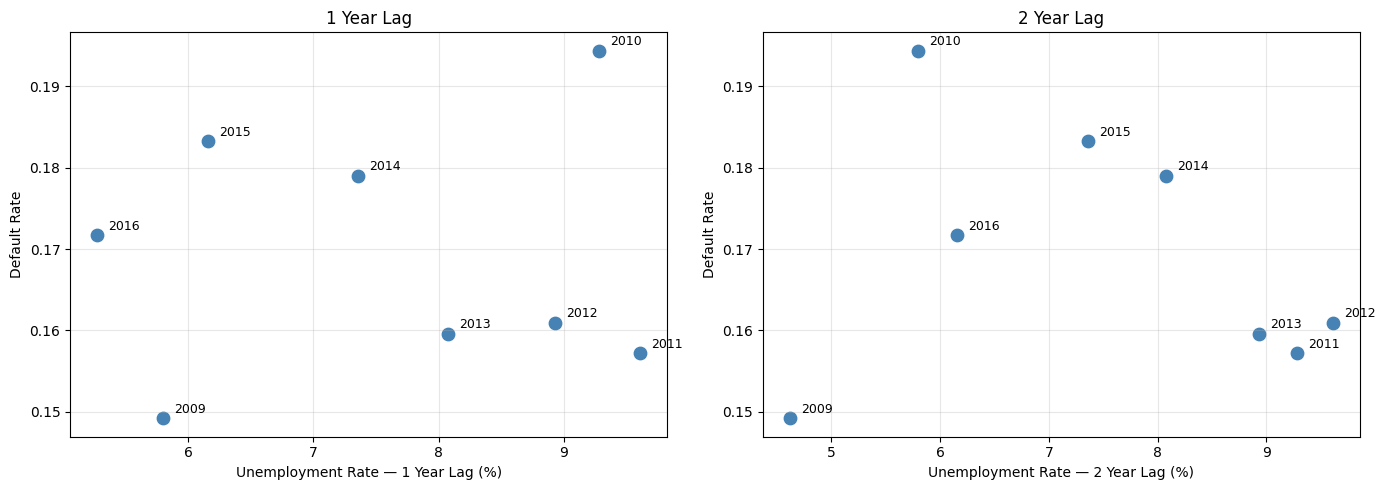

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#1 year lag plot
axes[0].scatter(macro_df_lagged['unemployment_lagged_1y'], macro_df_lagged['default_rate'],
                color='steelblue', s=80)
for _, row in macro_df_lagged.iterrows():
    axes[0].annotate(str(int(row['issue_year'])),
                     (row['unemployment_lagged_1y'], row['default_rate']),
                     textcoords='offset points', xytext=(8, 4), fontsize=9)
axes[0].set_xlabel('Unemployment Rate — 1 Year Lag (%)')
axes[0].set_ylabel('Default Rate')
axes[0].set_title('1 Year Lag')
axes[0].grid(True, alpha=0.3)

#2 year lag plot
axes[1].scatter(macro_df_lagged['unemployment_lagged_2y'], macro_df_lagged['default_rate'],
                color='steelblue', s=80)
for _, row in macro_df_lagged.iterrows():
    axes[1].annotate(str(int(row['issue_year'])),
                     (row['unemployment_lagged_2y'], row['default_rate']),
                     textcoords='offset points', xytext=(8, 4), fontsize=9)
axes[1].set_xlabel('Unemployment Rate — 2 Year Lag (%)')
axes[1].set_ylabel('Default Rate')
axes[1].set_title('2 Year Lag')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Our graphs are not much stronger than before. We continue using the $1$ year lag, as this best fits what we'd expect. Let us run ordinary least squares regression on the $1$ year lag graph, to obtain a line.

In [27]:
#run OLS regression of default rate on 1-year lagged unemployment
x = sm.add_constant(macro_df_lagged['unemployment_lagged_1y'])
y = macro_df_lagged['default_rate']

model_macro = sm.OLS(y, x).fit()
print(model_macro.summary())

                            OLS Regression Results                            
Dep. Variable:           default_rate   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.163
Method:                 Least Squares   F-statistic:                   0.02024
Date:                Sun, 10 May 2026   Prob (F-statistic):              0.892
Time:                        14:26:49   Log-Likelihood:                 22.632
No. Observations:                   8   AIC:                            -41.26
Df Residuals:                       6   BIC:                            -41.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

We see from the above result that the $r^2$ value is essentially useless. As it turns out, unemployment data is not a reliable indicator of how macroeconomic factors affect loan default rates, partially due to the abovementioned limitations. We are working with only $8$ years of data, which makes it inherently difficult to identify patters on such a small dataset. We must consider an alternate approach.

### GDP (Gross Domestic Product) Growth

We now try the same process, but with GDP growth rate instead of unemployment rate. Let us extract the data from the Federal Reserve and plot it against the default rate.

      gdp_growth
DATE            
2007       2.125
2008      -2.475
2009       0.150
2010       2.750
2011       1.575
2012       1.575
2013       3.025
2014       2.725
2015       2.100
2016       2.175


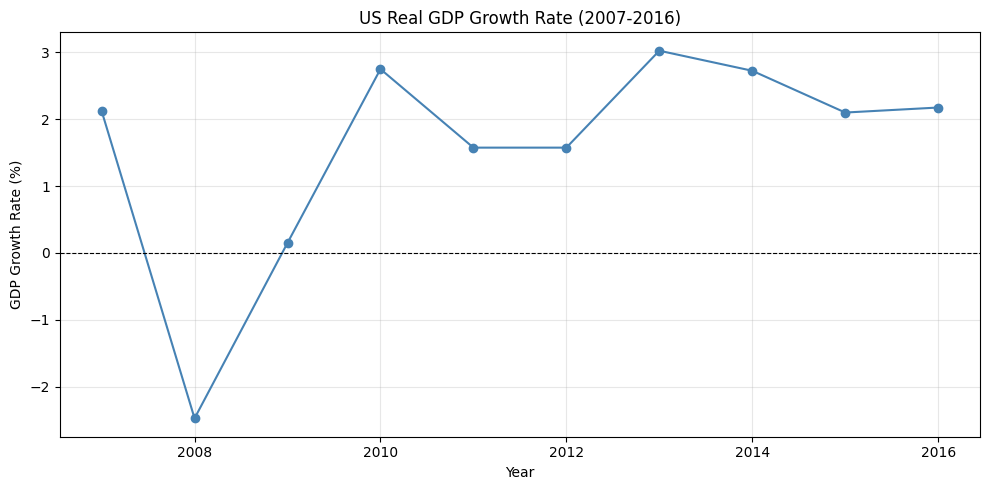

In [28]:
#fetch US real GDP growth rate from FRED
gdp = web.DataReader('A191RL1Q225SBEA', 'fred',
                      start=datetime(2007, 1, 1),
                      end=datetime(2016, 12, 31))

#convert quarterly to annual average
gdp.index = pd.to_datetime(gdp.index)
gdp_annual = gdp.resample('YE').mean()
gdp_annual.index = gdp_annual.index.year
gdp_annual.columns = ['gdp_growth']

print(gdp_annual)

#plot
plt.figure(figsize=(10, 5))
plt.plot(gdp_annual.index, gdp_annual['gdp_growth'],
         marker='o', color='steelblue', linewidth=1.5)
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Year')
plt.ylabel('GDP Growth Rate (%)')
plt.title('US Real GDP Growth Rate (2007-2016)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

As expected, a massive dip occurs in 2008. Let us plot this against default rate.

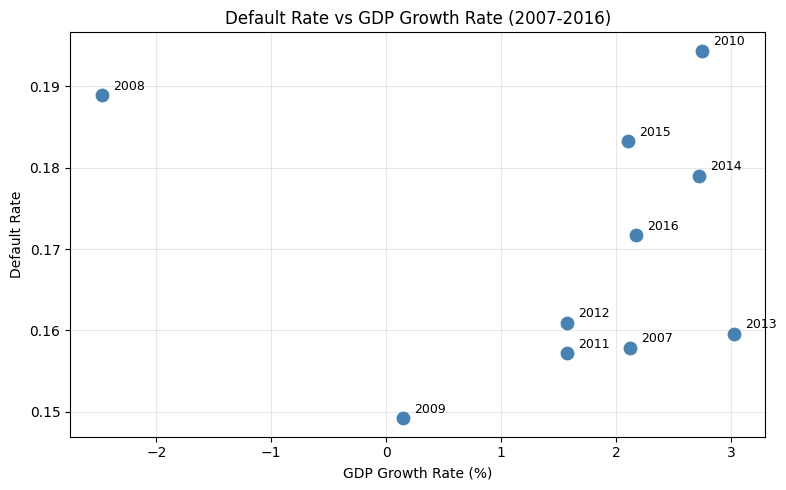

In [29]:
#merge GDP with default rates
macro_df = default_by_year_filtered.merge(
    gdp_annual,
    left_on='issue_year',
    right_index=True,
    how='inner'
)

#scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(macro_df['gdp_growth'], macro_df['default_rate'],
            color='steelblue', s=80, zorder=5)

for _, row in macro_df.iterrows():
    plt.annotate(str(int(row['issue_year'])),
                 (row['gdp_growth'], row['default_rate']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)

plt.xlabel('GDP Growth Rate (%)')
plt.ylabel('Default Rate')
plt.title('Default Rate vs GDP Growth Rate (2007-2016)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

It is clear yet again that this is also invaluable data. We can reasonably conclude that due to the lag between issue of the loan and the time of default, it will be difficult to find the macroeconomic factors affecting default rate. We are also limited by the small number of observations, being only a 10 year period.

## Calculating the Default Date

We can calculate an approximate default date for each loan using the available information. If we divide the `total_rec_prncp` (total recovered principal) by `installment`, we can work out how many months into the loan term the default occurred. We can then add these months to the `datetime` of the issue date to get a default date, as a new column. We do however make the assumption that all loan installments are monthly. Let us do this and replot the unemployment and GDP growth rate graphs.

In [30]:
#load raw data with required columns
df_defaults_macro = df_raw[df_raw['default_flag'] == 1].copy()

#estimate months to default from payments made
df_defaults_macro['months_to_default'] = (
    df_defaults_macro['total_rec_prncp'] / df_defaults_macro['installment']
)

#estimate default date
df_defaults_macro['estimated_default_date'] = (
    df_defaults_macro['issue_d'] + 
    pd.to_timedelta(df_defaults_macro['months_to_default'] * 30, unit='D')
)

df_defaults_macro['default_year'] = df_defaults_macro['estimated_default_date'].dt.year

#calculate default rate by estimated default year
default_by_default_year = df_defaults_macro.groupby('default_year').size()
total_by_default_year = df_raw.groupby(df_raw['issue_d'].dt.year).size()

print(df_defaults_macro[['issue_d', 'installment', 'total_rec_prncp', 
                           'months_to_default', 'estimated_default_date', 
                           'default_year']].head(10))

           issue_d  installment  total_rec_prncp  months_to_default  \
367120  2015-02-01       279.16          2434.00           8.719014   
1781031 2013-10-01       359.61          2452.48           6.819833   
1230912 2014-07-01       418.65          9279.28          22.164768   
185915  2015-08-01       667.06          7453.21          11.173223   
1665654 2017-03-01       503.54         14998.40          29.785916   
271414  2015-06-01       260.55          3921.04          15.049088   
630035  2017-07-01       285.43          2215.95           7.763550   
746136  2016-04-01       383.15           495.01           1.291948   
1856372 2013-04-01       246.20          4183.25          16.991267   
450869  2018-03-01       190.57          1080.93           5.672089   

               estimated_default_date  default_year  
367120  2015-10-20 13:41:24.768591489          2015  
1781031 2014-04-23 14:16:46.089930757          2014  
1230912 2016-04-25 22:37:57.893228235          2016  
18

   default_year  default_count  active_loans  default_rate
0          2008              7           109      0.064220
1          2009             21           357      0.058824
2          2010             54           892      0.060538
3          2011             79          1789      0.044159
4          2012            197          3979      0.049510
5          2013            447          9703      0.046068
6          2014           1056         19804      0.053323
7          2015           2114         37972      0.055673
8          2016           3475         55126      0.063037


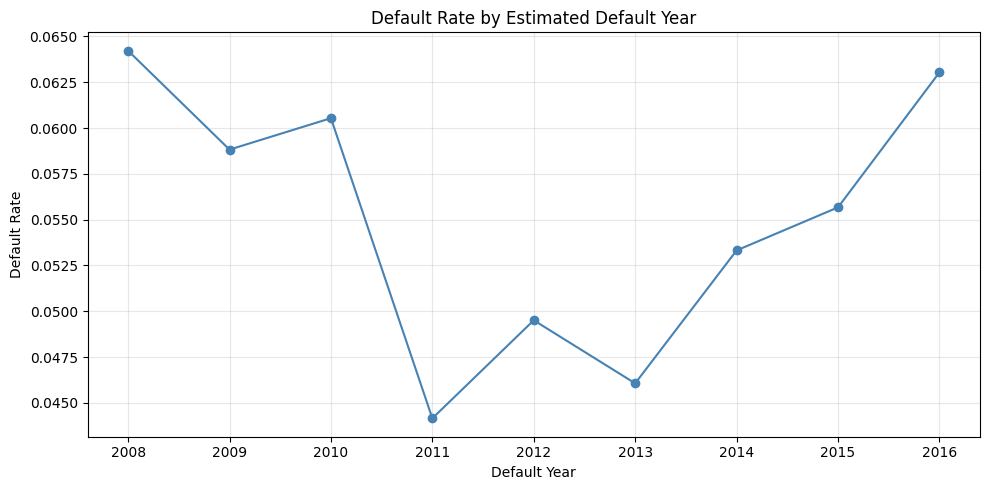

In [ ]:
#extract term as integer and calculate maturity year
df_raw['issue_year'] = df_raw['issue_d'].dt.year
df_raw['term_months'] = df_raw['term'].str.extract(r'(\d+)').astype(int)
df_raw['maturity_year'] = df_raw['issue_year'] + (df_raw['term_months'] / 12).astype(int)

#calculate number of active loans in each year
active_by_year = {}
for year in range(2008, 2017):
    active = df_raw[
        (df_raw['issue_year'] <= year) & 
        (df_raw['maturity_year'] >= year)
    ]
    active_by_year[year] = int(len(active))

active_df = pd.DataFrame({
    'default_year': list(active_by_year.keys()),
    'active_loans': list(active_by_year.values())
})

#count defaults by estimated default year
defaults_by_year = df_defaults_macro.groupby('default_year').size().reset_index()
defaults_by_year.columns = ['default_year', 'default_count']

#merge and calculate correct default rate
defaults_by_year = defaults_by_year.merge(active_df, on='default_year', how='inner')
defaults_by_year['default_rate'] = defaults_by_year['default_count'] / defaults_by_year['active_loans']

#filter to 2008-2016 to match data
defaults_by_year = defaults_by_year[
    (defaults_by_year['default_year'] >= 2008) & 
    (defaults_by_year['default_year'] <= 2016)
]

print(defaults_by_year)

#plot
plt.figure(figsize=(10, 5))
plt.plot(defaults_by_year['default_year'], defaults_by_year['default_rate'],
         marker='o', color='steelblue', linewidth=1.5)
plt.xlabel('Default Year')
plt.ylabel('Default Rate')
plt.title('Default Rate by Estimated Default Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This pattern is intuitive. There is a high default rate in 2008 followed by gradual lowering until the minimum in 2011, likely due to conservative loan terms for loans issued during the Global Financial Crisis (so less defaults in subsequent years). It then rises again over the next few years.

Now let us plot against unemployment.

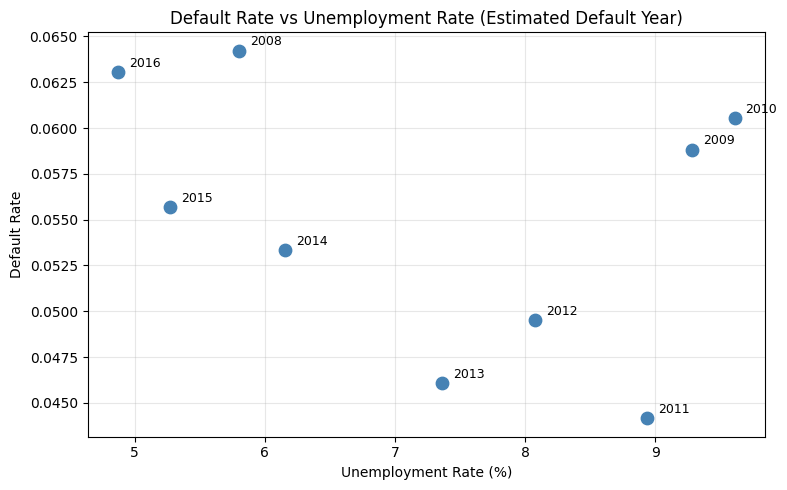

In [ ]:
#merge with unemployment
macro_df_new = defaults_by_year.merge(
    unemployment_annual,
    left_on='default_year',
    right_index=True,
    how='inner'
)

#scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(macro_df_new['unemployment_rate'], macro_df_new['default_rate'],
            color='steelblue', s=80, zorder=5)

for _, row in macro_df_new.iterrows():
    plt.annotate(str(int(row['default_year'])),
                 (row['unemployment_rate'], row['default_rate']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)

plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Default Rate')
plt.title('Default Rate (Estimated Default Year) vs Unemployment Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We now have a negative correlation visible, which is not as expected. Let us try plotting default rate against GDP growth again to see if that delivers better results before we conclude.

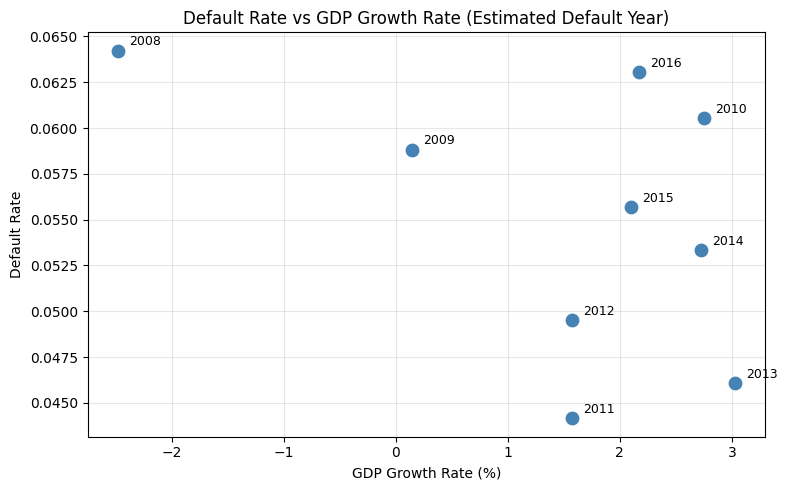

In [ ]:
#merge with GDP
macro_df_gdp = defaults_by_year.merge(
    gdp_annual,
    left_on='default_year',
    right_index=True,
    how='inner'
)

#scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(macro_df_gdp['gdp_growth'], macro_df_gdp['default_rate'],
            color='steelblue', s=80, zorder=5)

for _, row in macro_df_gdp.iterrows():
    plt.annotate(str(int(row['default_year'])),
                 (row['gdp_growth'], row['default_rate']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)

plt.xlabel('GDP Growth Rate (%)')
plt.ylabel('Default Rate')
plt.title('Default Rate (Estimated Default Year) vs GDP Growth Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

GDP growth rate also does not provide a clean graph.

## Conclusion

Unfortunately, it is clear that it is difficult to identify any relationship between macroeconomic measurements (unemployment, GDP growth rate) and the default rate, whether it be by year of loan issue or by estimated year of default. A few factors to consider:
- We have a very small number of observations. We only have $10$ years of loan data available, for which unprecendented conditions (the Global Financial Crisis) make it difficult to establish any standard relationship between default rate and our metrics.
- It is difficult to know when the borrowers who defaulted ran into financial difficulty. It is possible that borrowers were able to keep up repayments via savings for a while after they were affected by unemployment or slow growth.

Overall, we decide not to use any Federal Reserve data for our model. This presents a significant limitation to our model in that it does not factor in macroeconomic conditions when determining probability of default. This makes it difficult to predict the effect of future macroeconomic conditions on the probability of default. We are relying entirely on borrower profile.